In [96]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
import matplotlib.animation as animation

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dim = 2
N = 512
L = 10.0
n_lattice = int(ceil(N**(1/dim)))
spacing = L / n_lattice
indexing = torch.cartesian_prod(*[torch.arange(n_lattice) for _ in range(dim)]).to(device)
indexing = indexing[torch.randperm(indexing.size(0), device=device)[:N]]
x = (indexing + 0.5) * spacing
sigma2 = (0.5 * spacing + 0.5 * spacing * torch.rand(N, device=device))**2
v0 = (10*spacing)**dim
Kv = 0.001
Gamma = 1.0
gamma_r = 10.0
D = 0.01
use_self_propulsion = False
if dim  == 2 and use_self_propulsion:
    D_r = 0.1
    vel0 = 0.1
    thetas = 2 * np.pi * torch.rand(N, device=device)

In [98]:
def compute_quantities_isotropic(x, sigma2, use_pbc=False, L=None):
    v_i = sigma2**(x.shape[1] / 2)
    sigma2_ij = torch.einsum("i,j->ij", sigma2, sigma2)
    v_ij = sigma2_ij**(x.shape[1] / 2)
    r_ij = (x[:, None, :] - x[None, :, :])
    if use_pbc and L is not None:
        r_ij = r_ij - L * torch.round(r_ij / L)
    r2_ij = r_ij.pow(2).sum(dim=-1)
    r2_over_sigma2_ij = r2_ij / sigma2_ij
    w_ij = torch.exp(-r2_over_sigma2_ij / 2)
    w_ij *= v_i[:, None] * v_i[None, :]
    w_ij /= v_ij
    return v_i, v_ij, r_ij, r2_ij, sigma2_ij, r2_over_sigma2_ij, w_ij

In [99]:
dt = 1e-3
T_max = 100
n_steps = int(T_max / dt)
use_pbc = True
snapshot_interval = 50
snapshots_x = []
snapshots_sigma2 = []
system_size_init = L
system_size_final = 2*L/3
system_size = system_size_init
for step in range(n_steps):
    if use_pbc:
        x = x % system_size
    if step % snapshot_interval == 0:
        snapshots_x.append(x.cpu().numpy())
        snapshots_sigma2.append(sigma2.cpu().numpy())
    quantities = compute_quantities_isotropic(x, sigma2, use_pbc=use_pbc, L=L)
    v_i, v_ij, r_ij, r2_ij, sigma2_ij, r2_over_sigma2_ij, w_ij = quantities
    all_bulk_repulsion_forces = r_ij*w_ij[:, :, None] / sigma2_ij[:, :, None]
    bulk_repulsion_forces = torch.sum(all_bulk_repulsion_forces, dim=1)


    # self energies for sigma2
    self_forces_sigma2 = (v_i/sigma2)*(Kv*(v0-v_i) + (Gamma*(dim-2)/4)/torch.sqrt(sigma2))
    all_bulk_repulsion_forces_sigma2 = (-r2_over_sigma2_ij/sigma2_ij - 1/sigma2[:, None] + 1/sigma2_ij)*w_ij


    x += (dt*gamma_r)*bulk_repulsion_forces
    x += np.sqrt(2*D*dt)*torch.randn_like(x)

    sigma2 += (0.5*dt)*(self_forces_sigma2 + gamma_r*torch.sum(all_bulk_repulsion_forces_sigma2, dim=1))
    if dim == 2 and use_self_propulsion:
        vel = vel0 * torch.stack((torch.cos(thetas), torch.sin(thetas)), dim=-1)
        x += dt*vel
        thetas += np.sqrt(2*D_r*dt)*torch.randn_like(thetas)
    system_size = system_size_init + (system_size_final - system_size_init) * step / n_steps
snapshots_x = np.array(snapshots_x)
snapshots_sigma2 = np.array(snapshots_sigma2)

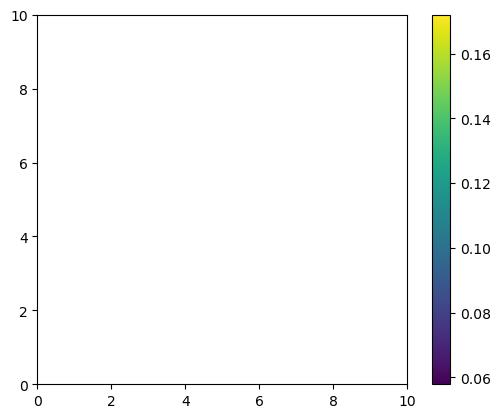

In [100]:
fig, ax = plt.subplots()

vmin, vmax = np.nanquantile(snapshots_sigma2, [0.1, 0.9])

scat = ax.scatter(
    snapshots_x[0, :, 0], snapshots_x[0, :, 1],
    c=snapshots_sigma2[0],
    s=(20*np.sqrt(snapshots_sigma2[0]))**2,
    cmap='viridis', vmin=vmin, vmax=vmax
)
plt.colorbar(scat, ax=ax)
plt.xlim(0, L)
plt.ylim(0, L)
ax.set_aspect('equal')

def update(frame):
    scat.set_offsets(snapshots_x[frame])
    scat.set_sizes((20*np.sqrt(snapshots_sigma2[frame]))**2)
    scat.set_array(snapshots_sigma2[frame])   # ← correct way
    return scat,

ani = animation.FuncAnimation(fig, update, frames=len(snapshots_x), blit=True)
ani.save('isotropic_evolution.mp4', fps=24)
plt.show()

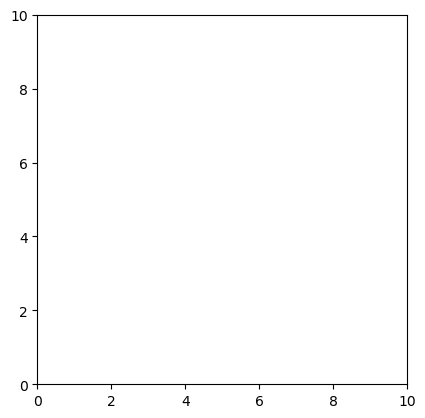

In [101]:
pos = x.cpu().numpy()
radius = np.sqrt(sigma2.cpu().numpy())
fig, ax = plt.subplots()
ax.scatter(pos[:, 0], pos[:, 1], c=radius, s=(20*radius)**2)
plt.xlim(0, L)
plt.ylim(0, L)
ax.set_aspect('equal')
plt.show()

In [ ]:
pos = x.cpu().numpy()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=20)
plt.show()